In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001962D5A8090> [0]

In [3]:
REGION = 'Nord'
YEAR = 2020

In [4]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [5]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [6]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.0


In [7]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (1448994, 24)


Text(0.5, 1.0, 'Year: 2020')

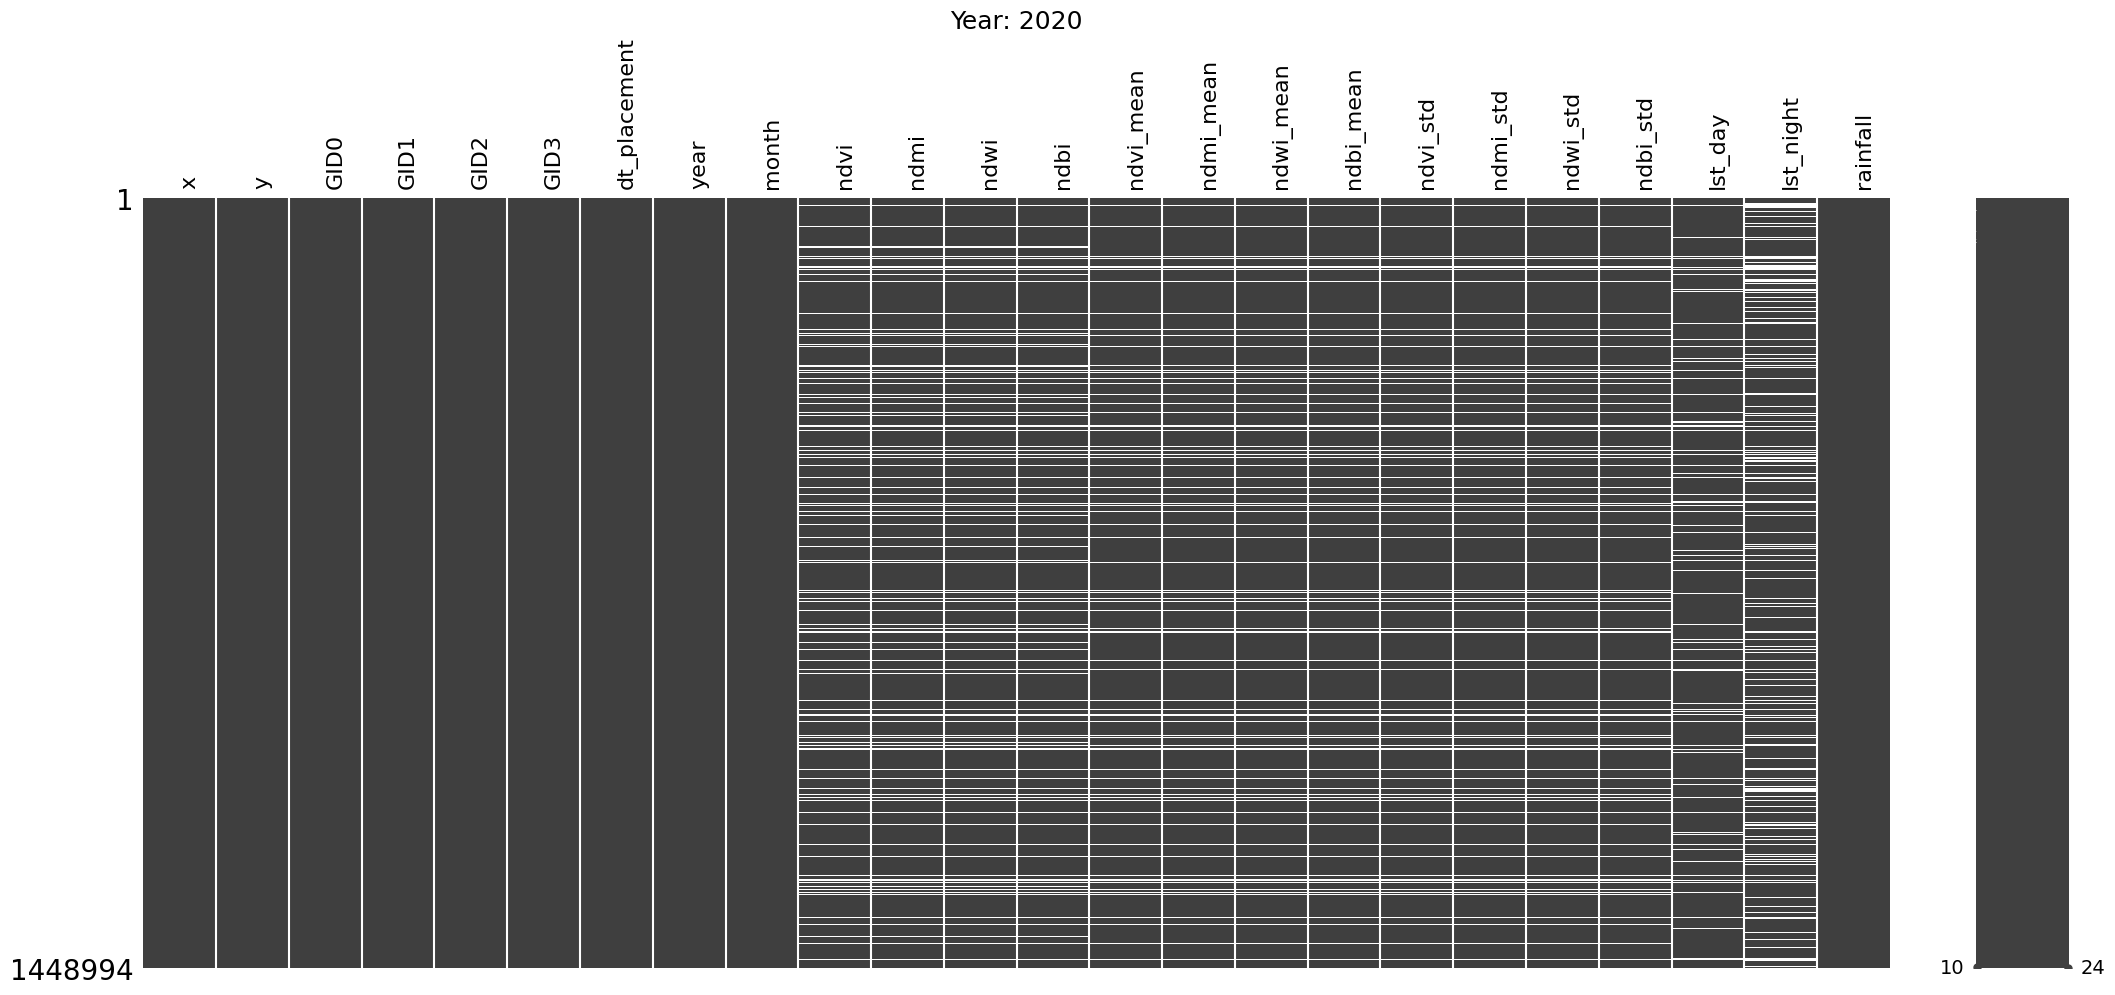

In [8]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [10]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [11]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.5,0.866
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0,NaN,0.5,0.866
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0,NaN,0.5,0.866
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.0,14596.5,0.5,0.866
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.0,14598.5,0.5,0.866


In [12]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.56021,9.29772,15102.128622,680.892978,2,151.604907,185.418439,180.092206,0.0,1.000000
1,13.59642,9.22586,6838.003488,1865.794331,1,201.794101,197.674022,183.049512,0.0,2.249840
2,13.59642,9.26179,9504.069954,2074.586084,1,136.247919,186.061883,180.318899,0.0,9.050964
3,13.59642,9.29772,12864.041385,781.399397,1,143.777456,188.894941,180.250312,0.0,2.000000
4,13.63262,9.18992,1899.383898,1344.931378,1,151.874866,187.347864,179.798661,0.0,1.000000


In [13]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.0,14596.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.0,14598.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735


Text(0.5, 1.0, 'Year: 2020')

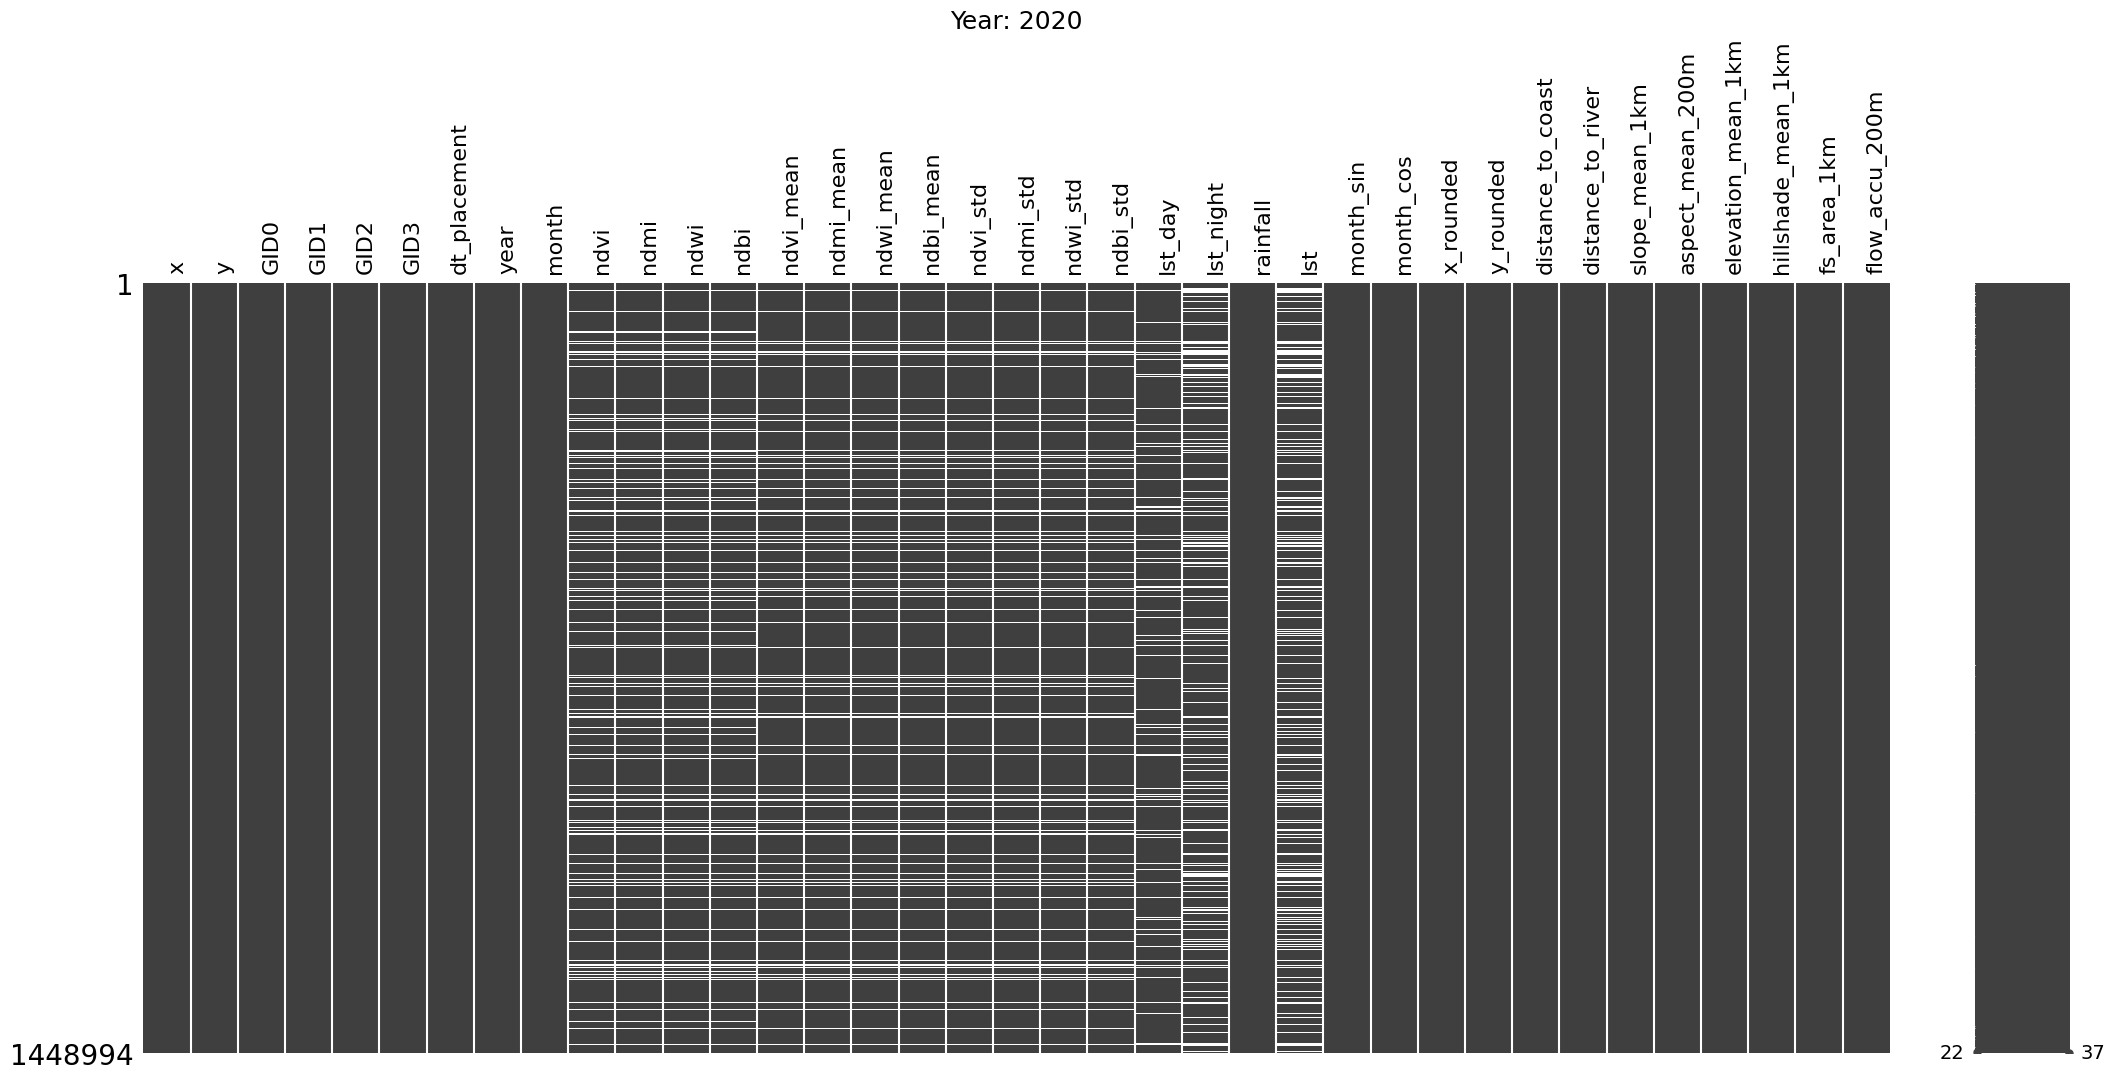

In [14]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [15]:
landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
75221,13.56021,9.29772,2020,31,99,36,99.0,30,99,12,12,1,6,7,2,0
75222,13.59642,9.22586,2020,31,99,36,99.0,30,99,12,12,3,5,8,2,0
75223,13.59642,9.26179,2020,31,98,36,96.0,30,98,12,12,1,6,7,2,0
75224,13.59642,9.29772,2020,31,99,36,99.0,30,99,12,12,1,6,7,2,0
75225,13.63262,9.18992,2020,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [16]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)

landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,98.0,30,99,12,12,1,6,7,2,0
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,98.0,30,99,12,12,1,6,7,2,0
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,98.0,30,99,12,12,1,6,7,2,0
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.0,14596.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,98.0,30,99,12,12,1,6,7,2,0
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.0,14598.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,98.0,30,99,12,12,1,6,7,2,0


In [17]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 90, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 90, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 90, 'lc_prop3'] = np.nan

In [18]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2020')

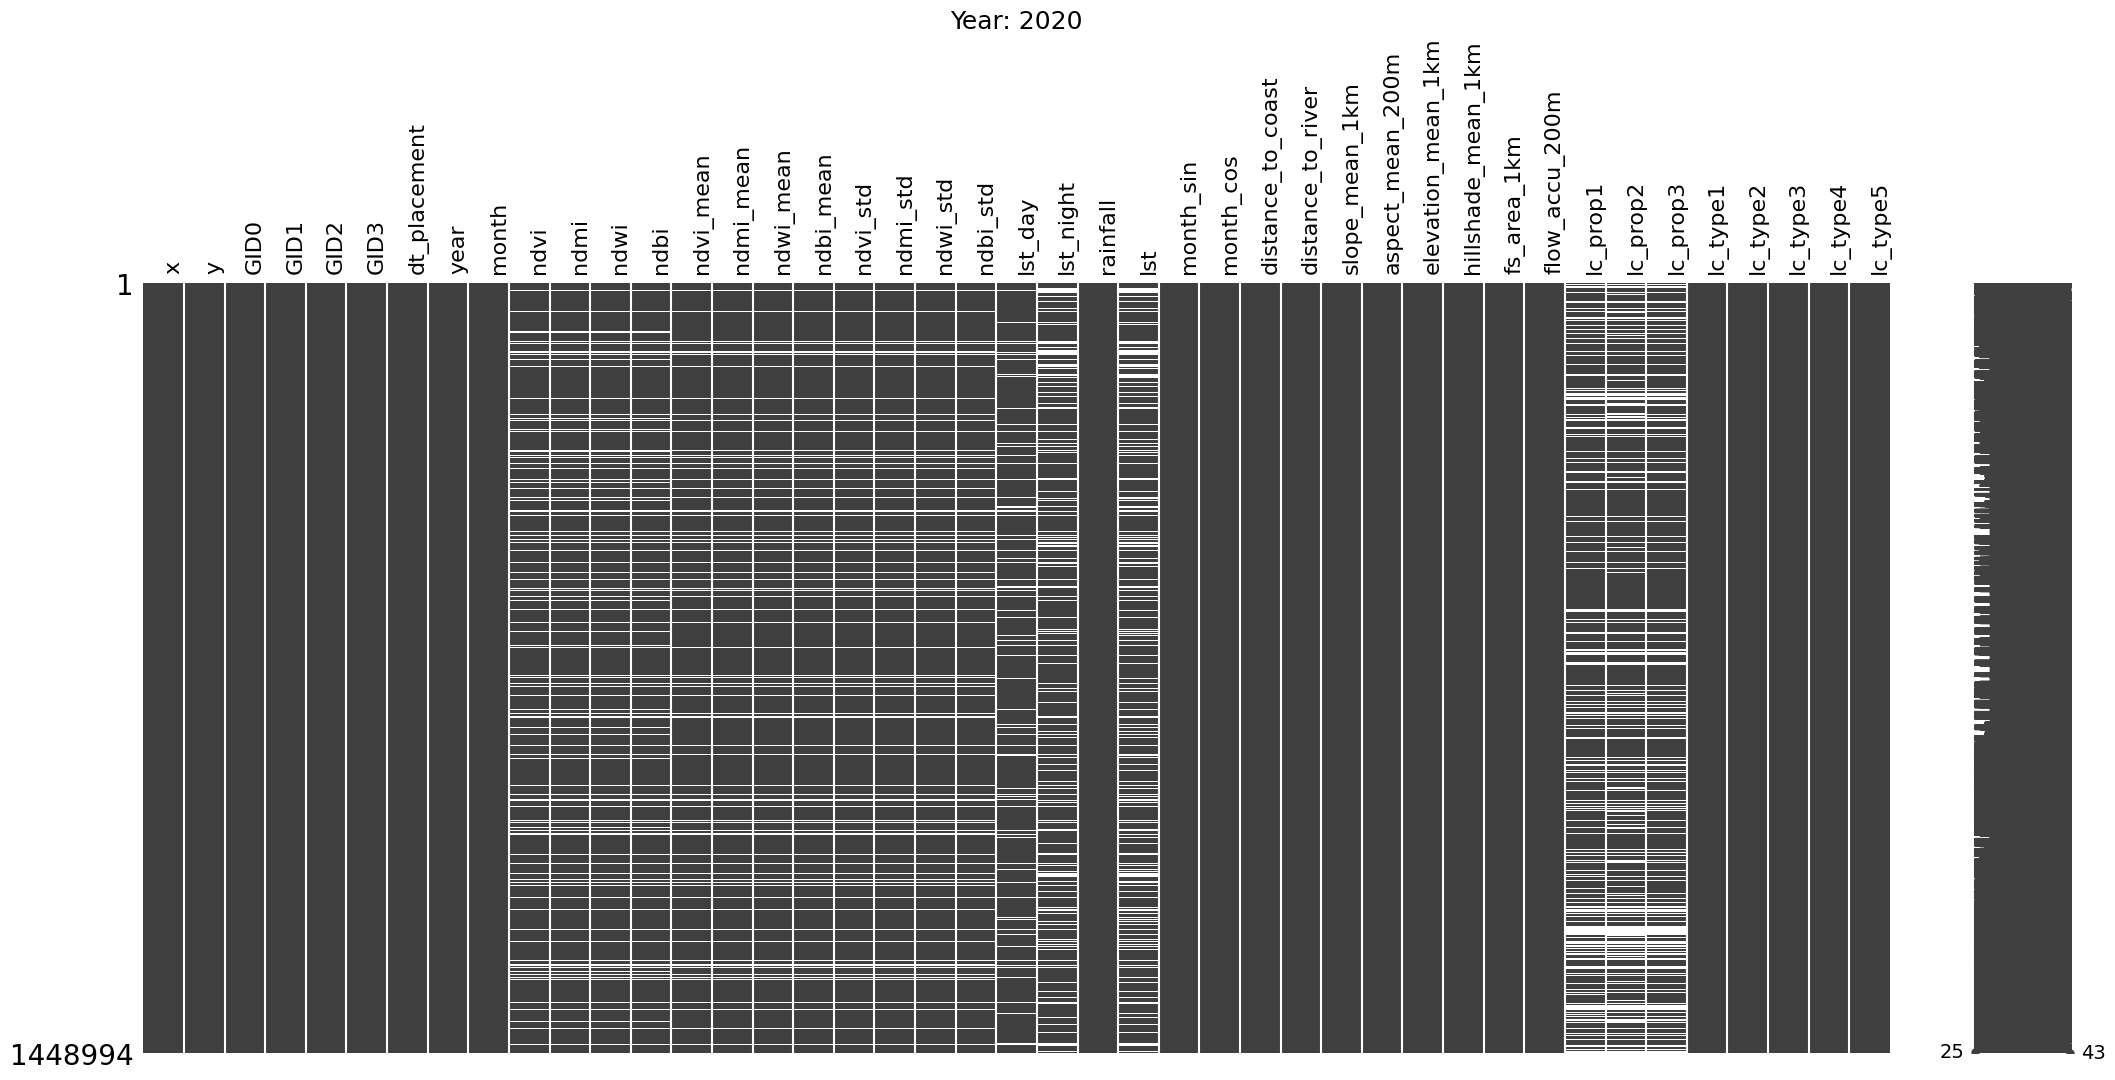

In [19]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [20]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.00,NaN,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.00,NaN,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.00,14596.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.00,14598.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-27,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.246605,-0.105652,-0.248674,0.105652,0.050398,0.050228,0.028863,0.050228,14943.0,14470.0,0.00,14706.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-28,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.246605,-0.105652,-0.248674,0.105652,0.050398,0.050228,0.028863,0.050228,14943.0,14470.0,0.00,14706.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-29,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.301446,-0.001540,-0.304972,0.001540,0.034961,0.039764,0.039052,0.039764,14943.0,14470.0,0.00,14706.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-30,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.301446,-0.001540,-0.304972,0.001540,0.034961,0.039764,0.039052,0.039764,15328.0,14470.0,0.00,14899.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4


In [21]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [22]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [23]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [24]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [25]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [26]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (53070, 51)


Text(0.5, 1.0, 'Year: 2020.0')

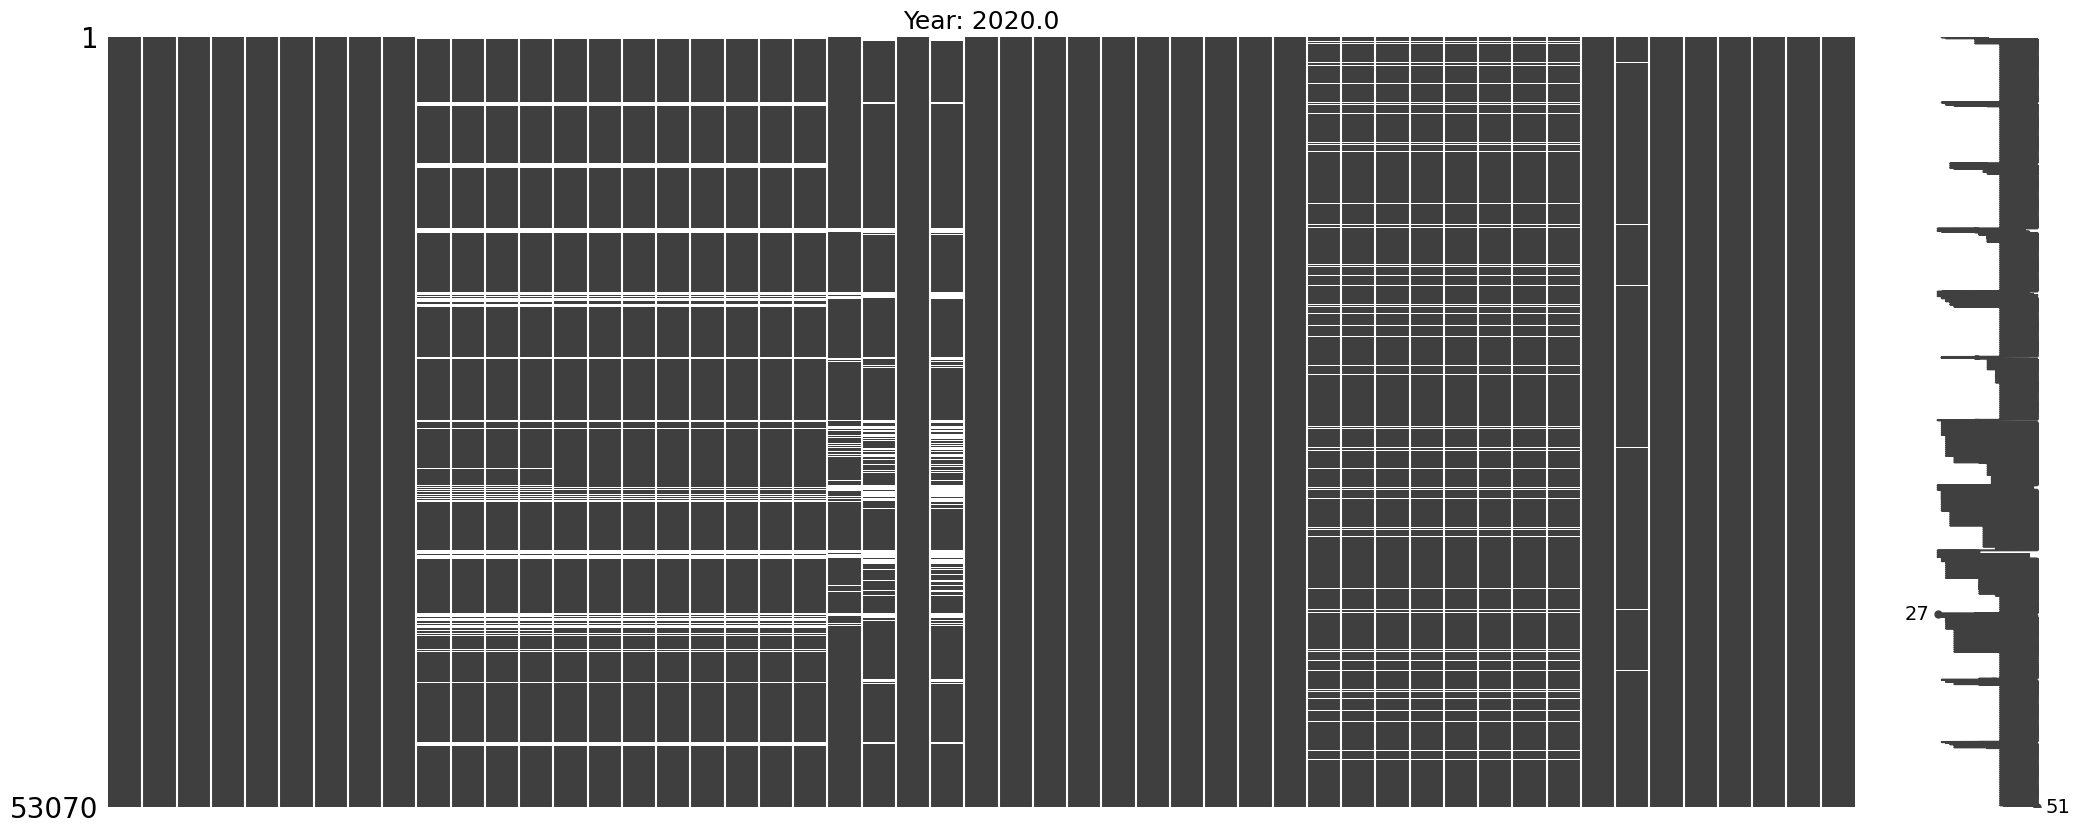

In [27]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=18)

In [28]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [29]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [30]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [31]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2020-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.782000,NaN,0.000000,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2020-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.091538,NaN,0.000026,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2020-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.594000,NaN,0.000000,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2020-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.533636,NaN,0.000000,NaN,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7
4,2020-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.350000,NaN,0.000000,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


In [32]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [33]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2020-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.782000,NaN,0.000000,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2020-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.091538,NaN,0.000026,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2020-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.594000,NaN,0.000000,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2020-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.533636,NaN,0.000000,NaN,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7
4,2020-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.350000,NaN,0.000000,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


Text(0.5, 1.0, 'Year: 2020')

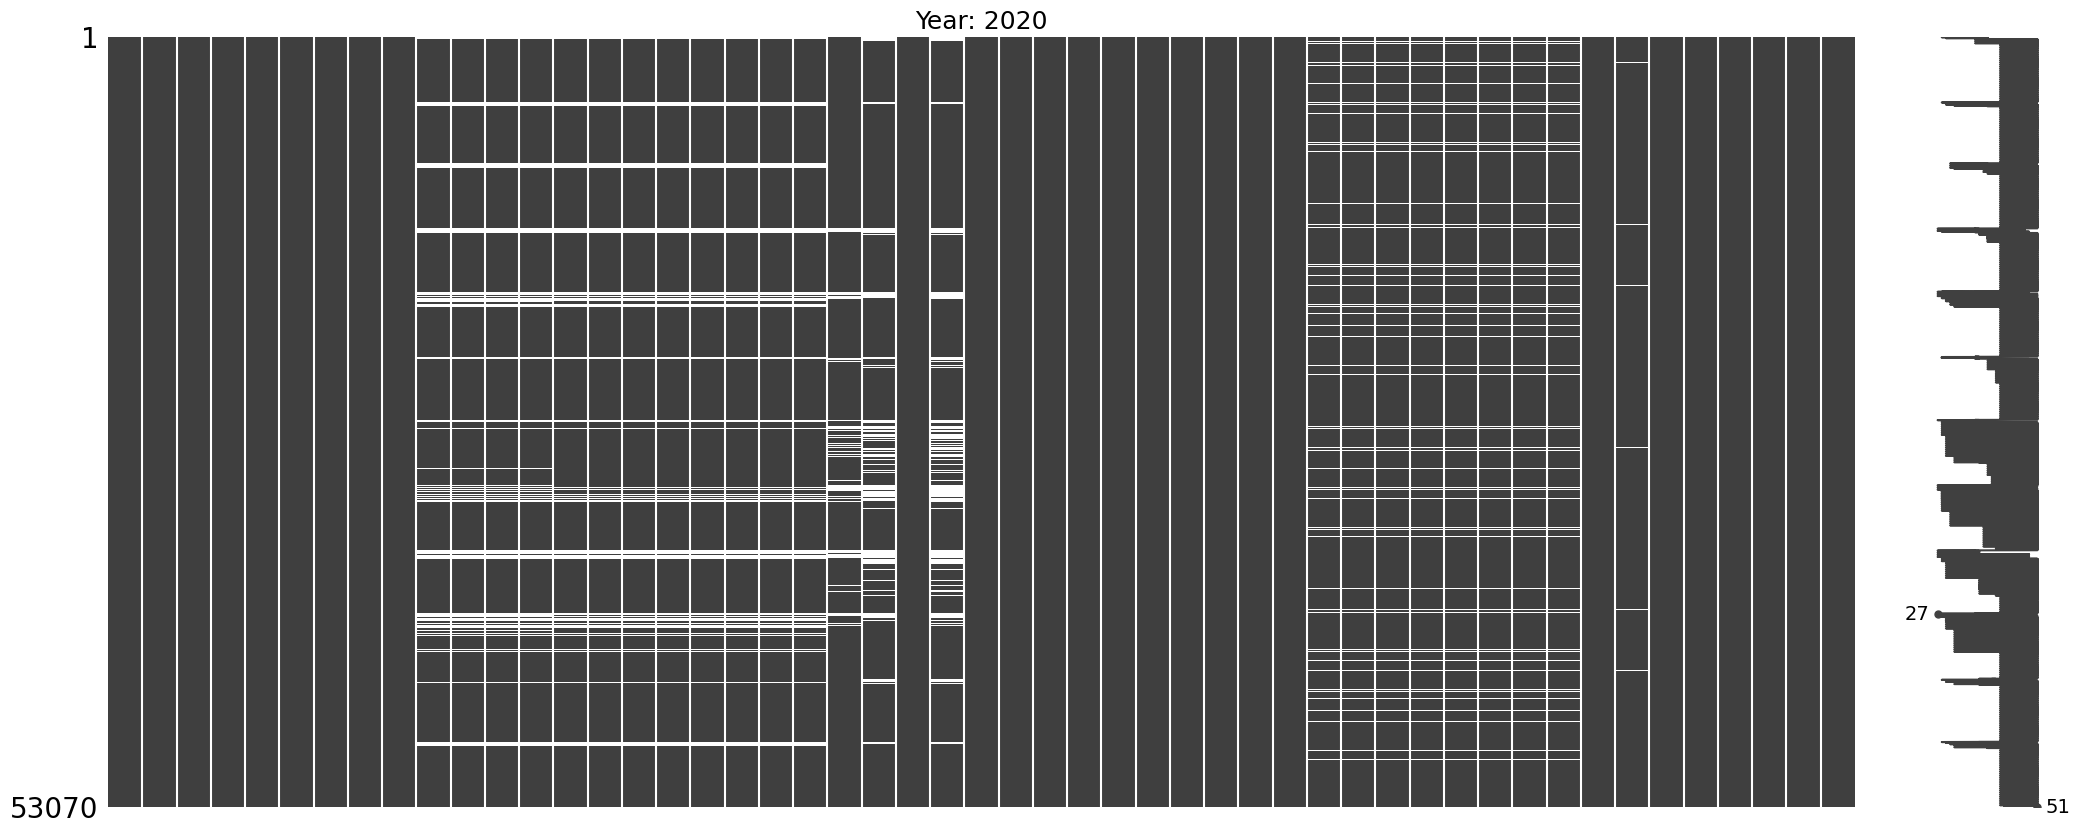

In [34]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=18)

In [35]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [36]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bibemi,adoumri,2020,1,15.114000,42.986000,0.106000
1,bibemi,adoumri,2020,2,14.800000,45.110000,1.957800
2,bibemi,adoumri,2020,3,15.506000,48.270000,9.507000
3,bibemi,adoumri,2020,4,20.582000,49.162000,57.253399
4,bibemi,adoumri,2020,5,23.558000,47.402000,156.235197
...,...,...,...,...,...,...,...
1735,touboro,yanli,2020,8,13.303333,28.698750,243.421930
1736,touboro,yanli,2020,9,19.994138,29.508065,516.052762
1737,touboro,yanli,2020,10,19.631935,32.888710,128.576481
1738,touboro,yanli,2020,11,16.666129,36.744839,12.008000


In [37]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [38]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2020-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.782000,NaN,0.000000,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.114000,42.986000,0.106000
1,2020-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.091538,NaN,0.000026,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,14.678205,41.943333,0.294641
2,2020-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.594000,NaN,0.000000,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,14.415333,40.704667,0.022000
3,2020-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.533636,NaN,0.000000,NaN,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7,14.013636,40.199091,0.323636
4,2020-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.350000,NaN,0.000000,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,14.610000,40.043333,0.123333


Text(0.5, 1.0, 'Year: 2020')

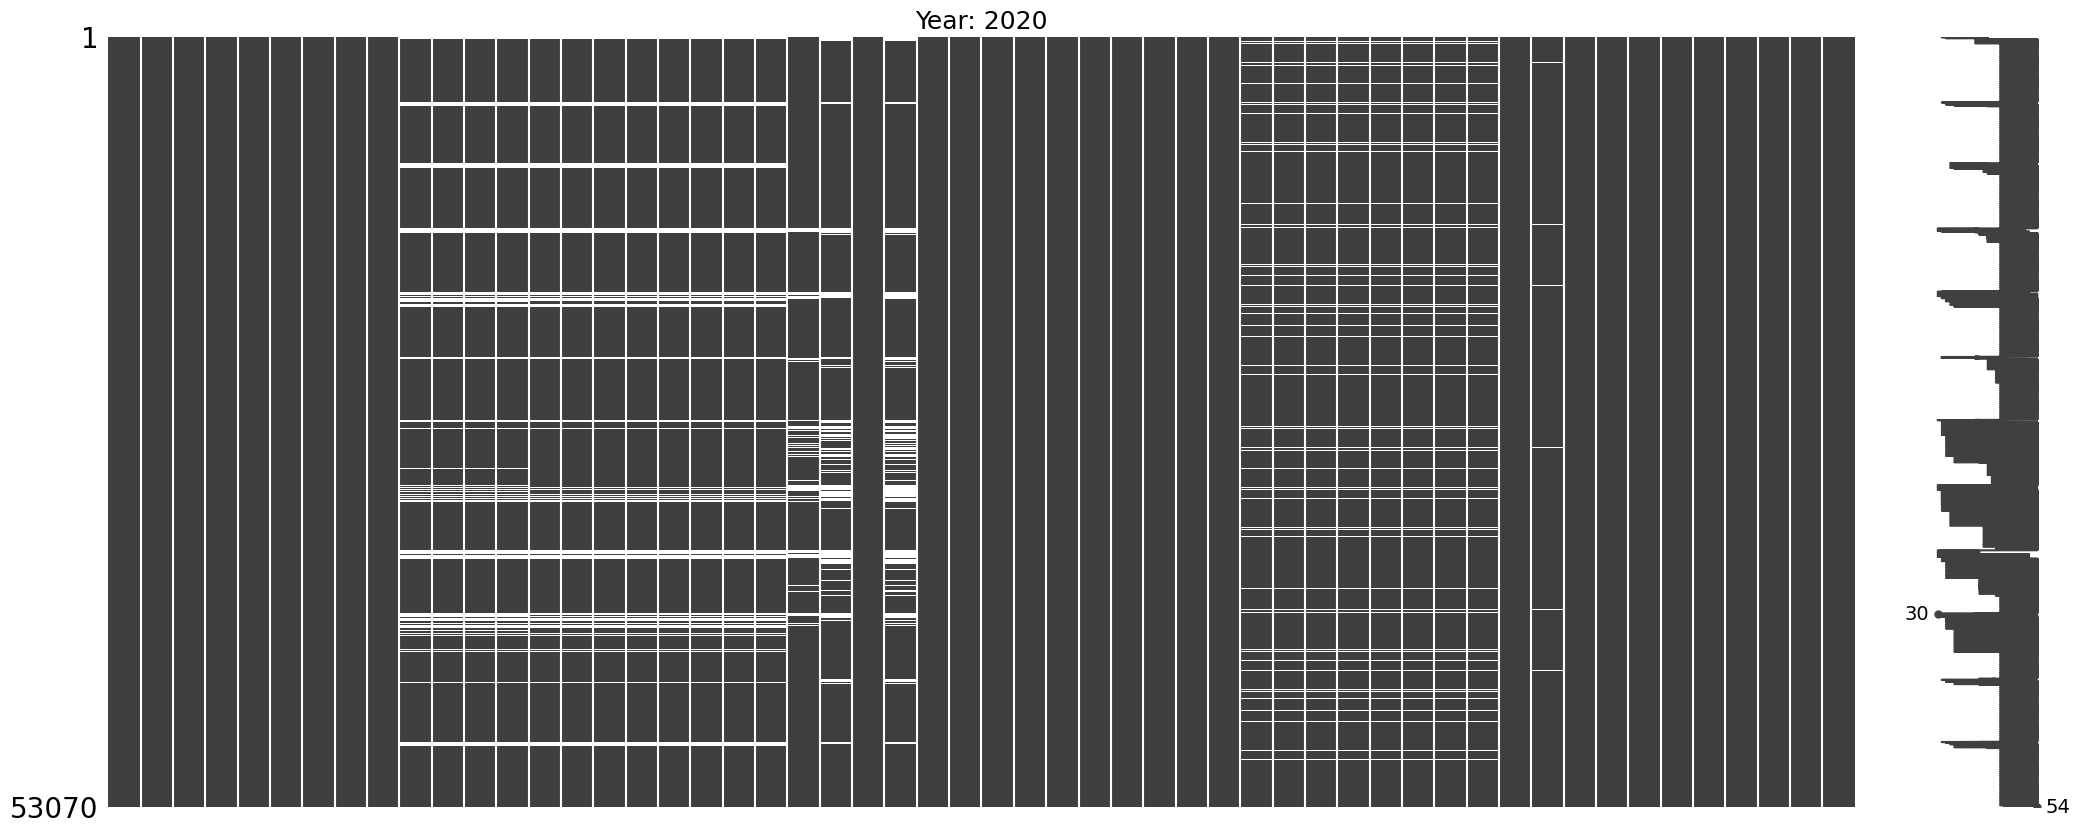

In [39]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [40]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [41]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2020-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.782000,NaN,0.000000,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.114000,42.986000,0.106000,2020-01
1,2020-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.091538,NaN,0.000026,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,14.678205,41.943333,0.294641,2020-01
2,2020-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.594000,NaN,0.000000,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,14.415333,40.704667,0.022000,2020-01
3,2020-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.533636,NaN,0.000000,NaN,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,1,6,7,14.013636,40.199091,0.323636,2020-01
4,2020-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.350000,NaN,0.000000,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,14.610000,40.043333,0.123333,2020-01


In [42]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [43]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [44]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2020-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020.0,1.0,0.181781,-0.114478,-0.323779,0.114478,0.176339,-0.120473,-0.323190,0.120473,0.007772,0.012932,0.011665,0.012932,35.678516,17.624759,0.003419,26.830828,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.114000,42.986000,0.106000
1,2020-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020.0,1.0,0.194450,-0.108916,-0.307892,0.108916,0.190360,-0.109905,-0.300965,0.109905,0.013320,0.013794,0.016521,0.013794,35.065699,18.386782,0.009505,26.939841,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.678205,41.943333,0.294641
2,2020-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020.0,1.0,0.210152,-0.074102,-0.312407,0.074102,0.206542,-0.074900,-0.311022,0.074900,0.011092,0.012142,0.010578,0.012142,33.771247,18.046598,0.000710,26.112138,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.415333,40.704667,0.022000
3,2020-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020.0,1.0,0.207863,-0.090273,-0.296017,0.090273,0.203008,-0.092189,-0.294960,0.092189,0.013707,0.020875,0.015336,0.020875,34.127654,17.328047,0.010440,25.912535,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.013636,40.199091,0.323636
4,2020-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020.0,1.0,0.192994,-0.021844,-0.258852,0.021844,0.179970,-0.015521,-0.246143,0.015521,0.024263,0.025591,0.037848,0.025591,33.420323,18.795977,0.003978,26.292644,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.610000,40.043333,0.123333


In [45]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (1740, 54)


Text(0.5, 1.0, 'Year: 2020.0')

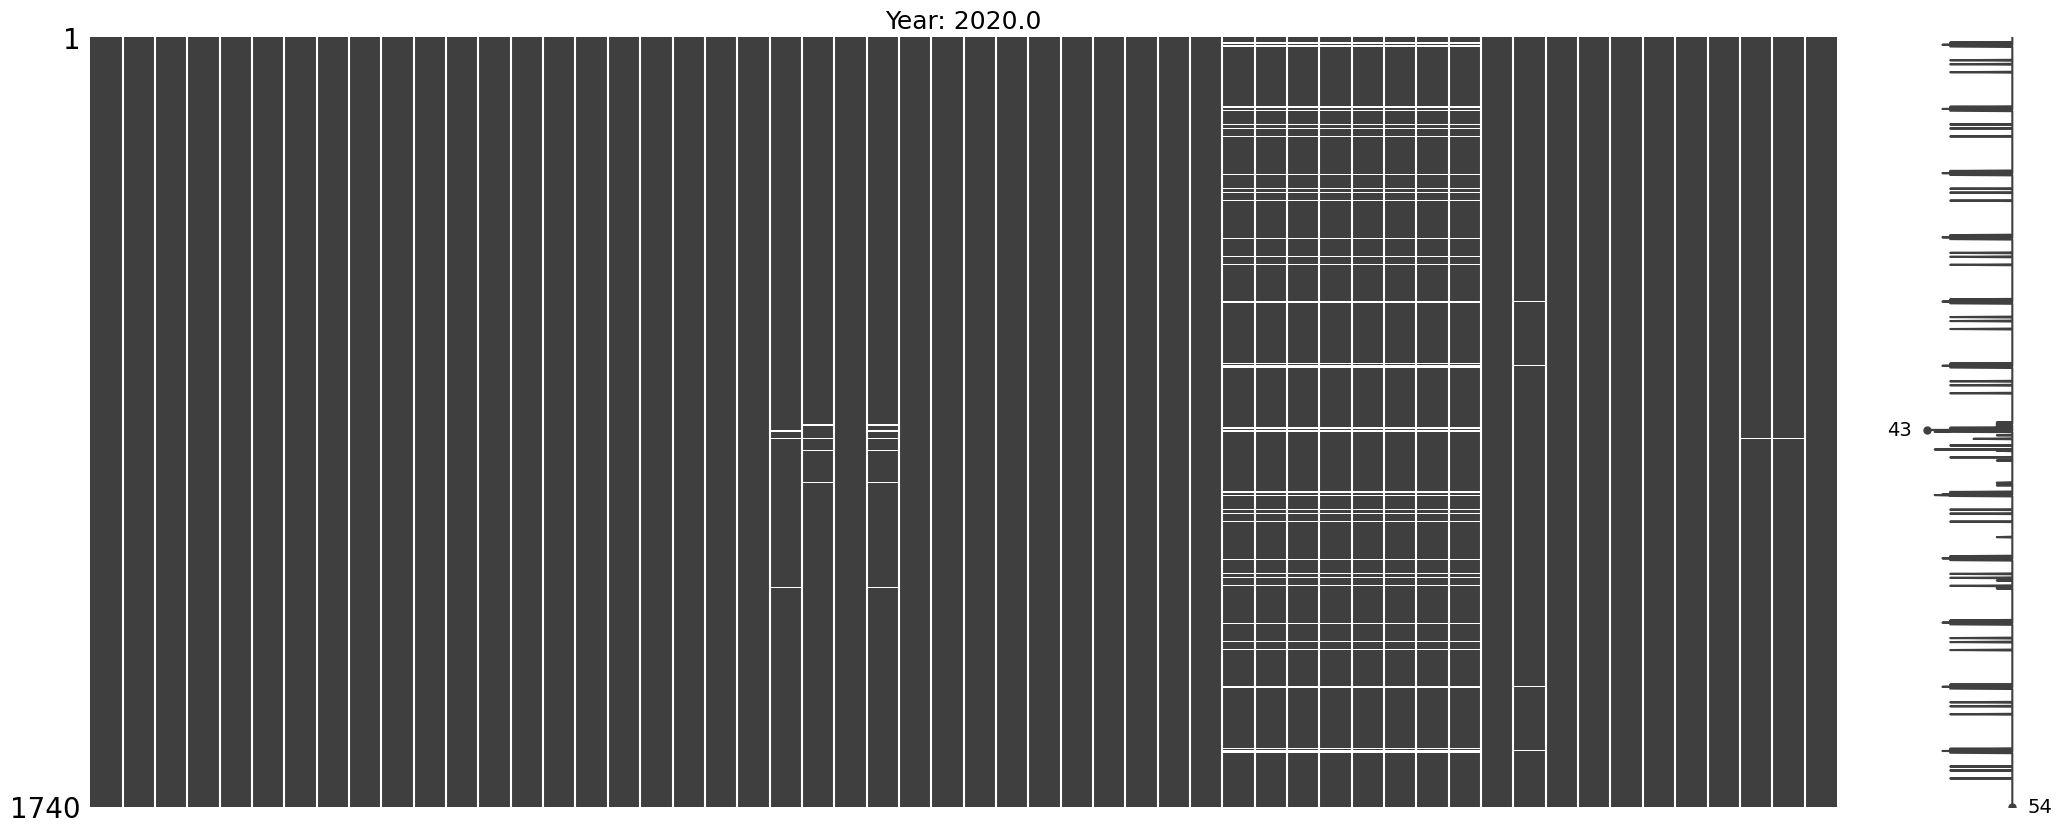

In [46]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [47]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [48]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [49]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [50]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2020-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020,1,0.181781,-0.114478,-0.323779,0.114478,0.176339,-0.120473,-0.323190,0.120473,0.007772,0.012932,0.011665,0.012932,35.678516,17.624759,0.003419,26.830828,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.114000,42.986000,0.106000
1,2020-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020,1,0.194450,-0.108916,-0.307892,0.108916,0.190360,-0.109905,-0.300965,0.109905,0.013320,0.013794,0.016521,0.013794,35.065699,18.386782,0.009505,26.939841,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.678205,41.943333,0.294641
2,2020-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020,1,0.210152,-0.074102,-0.312407,0.074102,0.206542,-0.074900,-0.311022,0.074900,0.011092,0.012142,0.010578,0.012142,33.771247,18.046598,0.000710,26.112138,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.415333,40.704667,0.022000
3,2020-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020,1,0.207863,-0.090273,-0.296017,0.090273,0.203008,-0.092189,-0.294960,0.092189,0.013707,0.020875,0.015336,0.020875,34.127654,17.328047,0.010440,25.912535,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.013636,40.199091,0.323636
4,2020-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020,1,0.192994,-0.021844,-0.258852,0.021844,0.179970,-0.015521,-0.246143,0.015521,0.024263,0.025591,0.037848,0.025591,33.420323,18.795977,0.003978,26.292644,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.610000,40.043333,0.123333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2020-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2020,12,0.361474,-0.022573,-0.332863,0.022573,0.363053,-0.019094,-0.333360,0.019094,0.027754,0.026588,0.021734,0.026588,31.479446,17.063010,0.001260,24.271228,0.0,1.000,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,16.132906,34.457179,0.039068
1736,2020-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2020,12,0.319698,-0.078010,-0.368968,0.078010,0.324195,-0.072784,-0.368821,0.072784,0.022442,0.023907,0.016711,0.023907,34.252959,18.633384,0.000066,26.443171,0.0,1.000,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,31.0,20.0,30.0,9.0,9.0,4.0,4.0,4.0,16.748966,37.468966,0.002034
1737,2020-12,nord,mayo-rey,toub

In [51]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [52]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2020-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020,1,0.181781,-0.114478,-0.323779,0.114478,0.176339,-0.120473,-0.323190,0.120473,0.007772,0.012932,0.011665,0.012932,35.678516,17.624759,0.003419,26.830828,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.114000,42.986000,0.106000,0.106000
1,2020-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020,1,0.194450,-0.108916,-0.307892,0.108916,0.190360,-0.109905,-0.300965,0.109905,0.013320,0.013794,0.016521,0.013794,35.065699,18.386782,0.009505,26.939841,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.678205,41.943333,0.294641,0.294641
2,2020-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020,1,0.210152,-0.074102,-0.312407,0.074102,0.206542,-0.074900,-0.311022,0.074900,0.011092,0.012142,0.010578,0.012142,33.771247,18.046598,0.000710,26.112138,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.415333,40.704667,0.022000,0.022000
3,2020-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020,1,0.207863,-0.090273,-0.296017,0.090273,0.203008,-0.092189,-0.294960,0.092189,0.013707,0.020875,0.015336,0.020875,34.127654,17.328047,0.010440,25.912535,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.013636,40.199091,0.323636,0.323636
4,2020-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020,1,0.192994,-0.021844,-0.258852,0.021844,0.179970,-0.015521,-0.246143,0.015521,0.024263,0.025591,0.037848,0.025591,33.420323,18.795977,0.003978,26.292644,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.610000,40.043333,0.123333,0.123333


In [53]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [54]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [55]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2020-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2020,1,0.181781,-0.114478,-0.323779,0.114478,0.176339,-0.120473,-0.323190,0.120473,0.007772,0.012932,0.011665,0.012932,35.678516,17.624759,0.003419,26.830828,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.114000,42.986000,0.106000,0.106000,30.791667,22.416667,64.047619,323.656898,49.0,14.0,35.0,29.500000,29.333333,33.833333,27.500000,1693.0,472.0,0.0,114.061608,1069.0,1.0,795.0,827.0
1,2020-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2020,1,0.194450,-0.108916,-0.307892,0.108916,0.190360,-0.109905,-0.300965,0.109905,0.013320,0.013794,0.016521,0.013794,35.065699,18.386782,0.009505,26.939841,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.678205,41.943333,0.294641,0.294641,29.583333,20.666667,59.047619,334.278962,49.0,14.0,35.0,25.333333,29.000000,33.666667,25.333333,1628.0,474.0,0.0,115.215162,1055.0,1.0,208.0,1055.0
2,2020-01,nord,benoue,bibemi,bide,13.972945,9.422292,2020,1,0.210152,-0.074102,-0.312407,0.074102,0.206542,-0.074900,-0.311022,0.074900,0.011092,0.012142,0.010578,0.012142,33.771247,18.046598,0.000710,26.112138,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.415333,40.704667,0.022000,0.022000,29.875000,20.416667,56.712963,299.336387,50.0,14.0,36.0,27.166667,29.166667,34.000000,27.000000,1607.0,519.0,0.0,122.666719,1068.0,0.0,162.0,889.0
3,2020-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2020,1,0.207863,-0.090273,-0.296017,0.090273,0.203008,-0.092189,-0.294960,0.092189,0.013707,0.020875,0.015336,0.020875,34.127654,17.328047,0.010440,25.912535,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.013636,40.199091,0.323636,0.323636,29.875000,21.916667,60.879630,292.423261,50.0,14.0,36.0,27.166667,28.500000,33.833333,27.166667,1650.0,461.0,0.0,114.610563,1051.0,1.0,189.0,1051.0
4,2020-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2020,1,0.192994,-0.021844,-0.258852,0.021844,0.179970,-0.015521,-0.246143,0.015521,0.024263,0.025591,0.037848,0.025591,33.420323,18.795977,0.003978,26.292644,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,14.610000,40.043333,0.123333,0.123333,30.500000,20.166667,54.504505,316.227766,51.0,14.0,37.0,28.833333,29.000000,34.333333,27.666667,1695.0,534.0,0.0,122.511846,1152.0,0.0,148.0,962.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

Text(0.5, 1.0, 'Year: 2020')

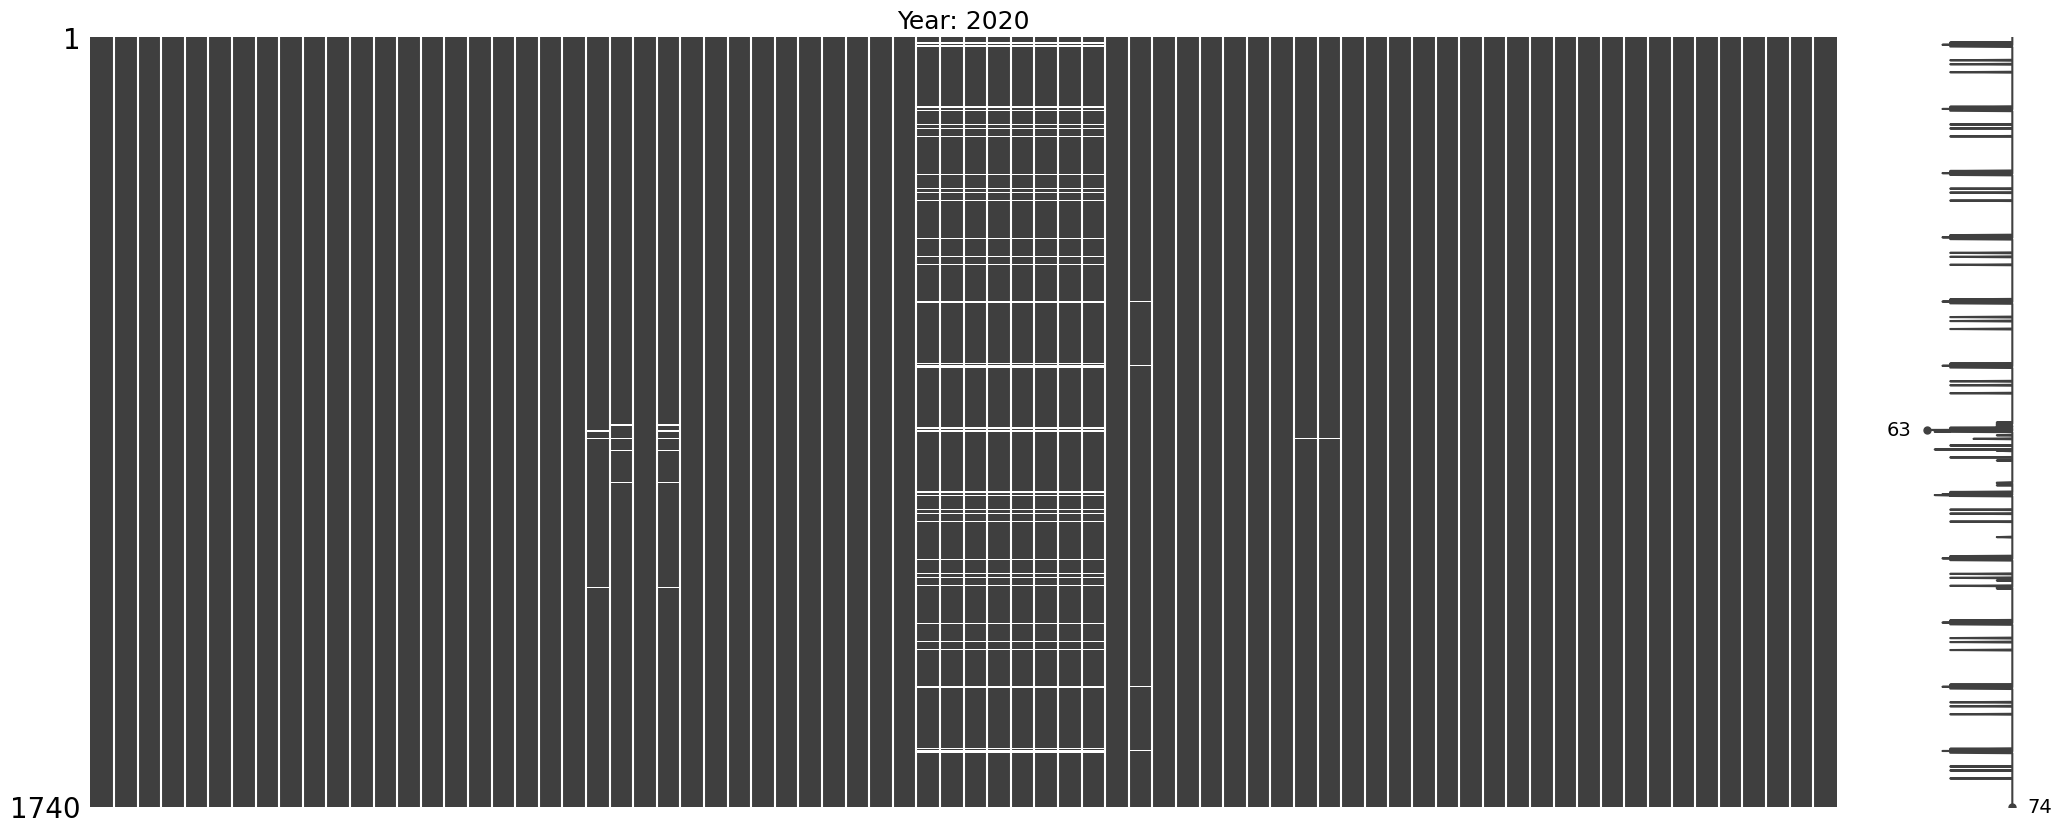

In [56]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [57]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [58]:
dataset.shape

(1740, 74)

In [59]:
new_order = ['dt_placement',
             'year',
             'month',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [60]:
dataset = dataset[new_order]

In [61]:
dataset.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2020-01,2020,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.181781,-0.114478,-0.323779,0.114478,0.176339,-0.120473,-0.323190,0.120473,0.007772,0.012932,0.011665,0.012932,26.83,35.68,17.62,15.11,42.99,0.0034,0.1060,0.1060,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,30.79,22.42,64.05,323.66,49.0,14.0,35.0,29.50,29.33,33.83,27.50,1693.0,472.0,0.0,114.06,1069.0,1.0,795.0,827.0
1,2020-01,2020,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.194450,-0.108916,-0.307892,0.108916,0.190360,-0.109905,-0.300965,0.109905,0.013320,0.013794,0.016521,0.013794,26.94,35.07,18.39,14.68,41.94,0.0095,0.2946,0.2946,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.58,20.67,59.05,334.28,49.0,14.0,35.0,25.33,29.00,33.67,25.33,1628.0,474.0,0.0,115.22,1055.0,1.0,208.0,1055.0
2,2020-01,2020,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.210152,-0.074102,-0.312407,0.074102,0.206542,-0.074900,-0.311022,0.074900,0.011092,0.012142,0.010578,0.012142,26.11,33.77,18.05,14.42,40.70,0.0007,0.0220,0.0220,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,29.88,20.42,56.71,299.34,50.0,14.0,36.0,27.17,29.17,34.00,27.00,1607.0,519.0,0.0,122.67,1068.0,0.0,162.0,889.0
3,2020-01,2020,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.207863,-0.090273,-0.296017,0.090273,0.203008,-0.092189,-0.294960,0.092189,0.013707,0.020875,0.015336,0.020875,25.91,34.13,17.33,14.01,40.20,0.0104,0.3236,0.3236,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,1,6,7,29.88,21.92,60.88,292.42,50.0,14.0,36.0,27.17,28.50,33.83,27.17,1650.0,461.0,0.0,114.61,1051.0,1.0,189.0,1051.0
4,2020-01,2020,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.192994,-0.021844,-0.258852,0.021844,0.179970,-0.015521,-0.246143,0.015521,0.024263,0.025591,0.037848,0.025591,26.29,33.42,18.80,14.61,40.04,0.0040,0.1233,0.1233,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,30.50,20.17,54.50,316.23,51.0,14.0,37.0,28.83,29.00,34.33,27.67,1695.0,534.0,0.0,122.51,1152.0,0.0,148.0,962.0


In [62]:
dataset.shape

(1740, 74)

In [63]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 74 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1740 non-null   period[M]
 1   year                    1740 non-null   int32    
 2   month                   1740 non-null   int32    
 3   month_sin               1740 non-null   float64  
 4   month_cos               1740 non-null   float64  
 5   GID0                    1740 non-null   object   
 6   GID1                    1740 non-null   object   
 7   GID2                    1740 non-null   object   
 8   GID3                    1740 non-null   object   
 9   x                       1740 non-null   float64  
 10  y                       1740 non-null   float64  
 11  ndvi                    1740 non-null   float64  
 12  ndmi                    1740 non-null   float64  
 13  ndwi                    1740 non-null   float64  
 14  ndbi    

In [64]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)